In [4]:
#scikit-rf) is a library made specially for RF/VNA/S-parameter data.
!pip install scikit-rf


In [5]:
import skrf as rf
#rf.Network(...) loads Touchstone S1P file into an RF network object.
ntw = rf.Network('anuS1P1.s1p')
ntw
#ntw now contains: frequency points, S11 complex values, impedance, Smith chart data


1-Port Network: 'anuS1P1',  5000000.0-505000000.0 Hz, 201 pts, z0=[50.+0.j]

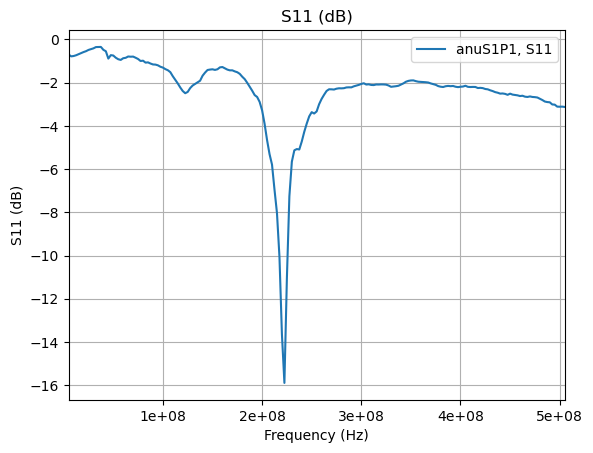

In [6]:
import matplotlib.pyplot as plt

ntw.plot_s_db() #S11(dB)=20log10​∣S11∣
plt.title("S11 (dB)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("S11 (dB)")
plt.grid(True)
plt.show()


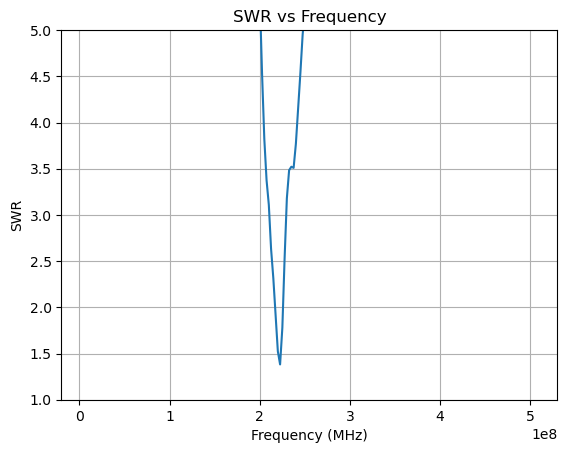

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Compute |S11|
s11 = ntw.s[:,0,0]
mag = np.abs(s11)

# Compute SWR
swr = (1 + mag) / (1 - mag)

# Frequency (in MHz)
freq_mhz = ntw.f

plt.plot(freq_mhz, swr)
plt.title("SWR vs Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("SWR")
plt.grid(True)
plt.ylim(1, 5)   # adjust if needed
plt.show()


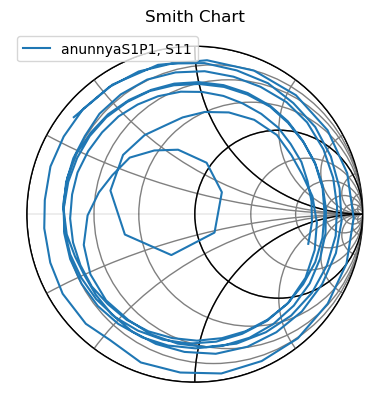

In [50]:
ntw.plot_s_smith()
plt.title("Smith Chart")
plt.show()


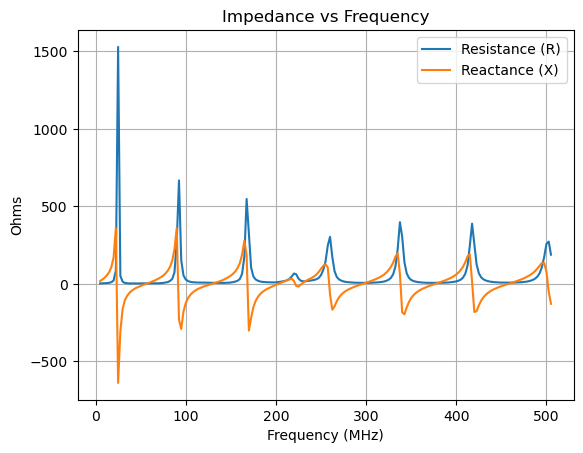

In [52]:
# Extract impedance
impedance = ntw.z[:,0,0]

# Real and imaginary parts
freq = ntw.f
R = impedance.real
X = impedance.imag

# Plot impedance
plt.plot(freq/1e6, R, label='Resistance (R)')
plt.plot(freq/1e6, X, label='Reactance (X)')
plt.title("Impedance vs Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Ohms")
plt.grid(True)
plt.legend()
plt.show()


In [54]:
import numpy as np

idx = np.argmin(np.abs(X))   # smallest reactance
print("Resonant Frequency ~", freq[idx]/1e6, "MHz")
print("Impedance at resonance:", impedance[idx])


Resonant Frequency ~ 202.5 MHz
Impedance at resonance: (11.041339075122316-0.26944608899725997j)


In [56]:
mask = ntw.s_db[:,0,0] < -10
bw_low = freq[mask][0]
bw_high = freq[mask][-1]

print("10 dB Bandwidth:", bw_low, "MHz to", bw_high, "MHz")
print("Total BW:", bw_high - bw_low, "MHz")

10 dB Bandwidth: 217500000.0 MHz to 225000000.0 MHz
Total BW: 7500000.0 MHz
